# Graph Observation Spaces — IEEE 14-Bus Grid

Loads an observation from `l2rpn_case14_sandbox` **after a topology action that
splits substation 1** (generator 0 and line-origin 2 moved to bus 2).

All four converters are shown side-by-side. The two converters that encode
connectivity via edge metadata use `EdgeStyle` to colour edges:

| Converter | Colouring |
|---|---|
| `HeterogeneousGraphObservationConverter` | orange `--` = powerline · green = same-bus · crimson `:` = diff-bus |
| `ElementGraphObservationConverter` | green = active connection · gray = inactive |


In [1]:
import sys
from pathlib import Path

import grid2op
import matplotlib.pyplot as plt

project_root = Path.cwd().parent.parent
src_root = project_root / "src"
for p in (str(project_root), str(src_root)):
    if p not in sys.path:
        sys.path.insert(0, p)

from grid2op_env.observation_converter import (
    ElementGraphObservationConverter,
    GraphObservationConverter,
    HeterogeneousGraphObservationConverter,
    SubstationGraphObservationConverter,
    EDGE_INDEX, EDGE_MASK,
)
from visualization.utils import PlottingArgs, get_node_styles, get_edge_styles, visualize_graph

plt.style.use("default")

/home/adrian/.conda/envs/L2RPN/lib/python3.10/site-packages/grid2op/MakeEnv/Make.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/home/adrian/.conda/envs/L2RPN/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-08-14 11:26:21,061	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-08-14 11:26:26,693	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
env = grid2op.make("l2rpn_case14_sandbox")
env.reset()

action = env.action_space({
    "set_bus": {
        "generators_id": [(0, 2)],
        "lines_or_id":   [(2, 2)],
    }
})
obs, _, done, _ = env.step(action)
if done:
    print("Topology action caused game-over — using initial observation.")
    obs = env.reset()
else:
    print(f"Elements on bus 2: {(obs.topo_vect == 2).sum()}")

Elements on bus 2: 2


/home/adrian/.conda/envs/L2RPN/lib/python3.10/site-packages/grid2op/Backend/pandaPowerBackend.py:957: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  self._grid.line["in_service"].iat[id_powerline_backend] = True
/home/adrian/.conda/envs/L2RPN

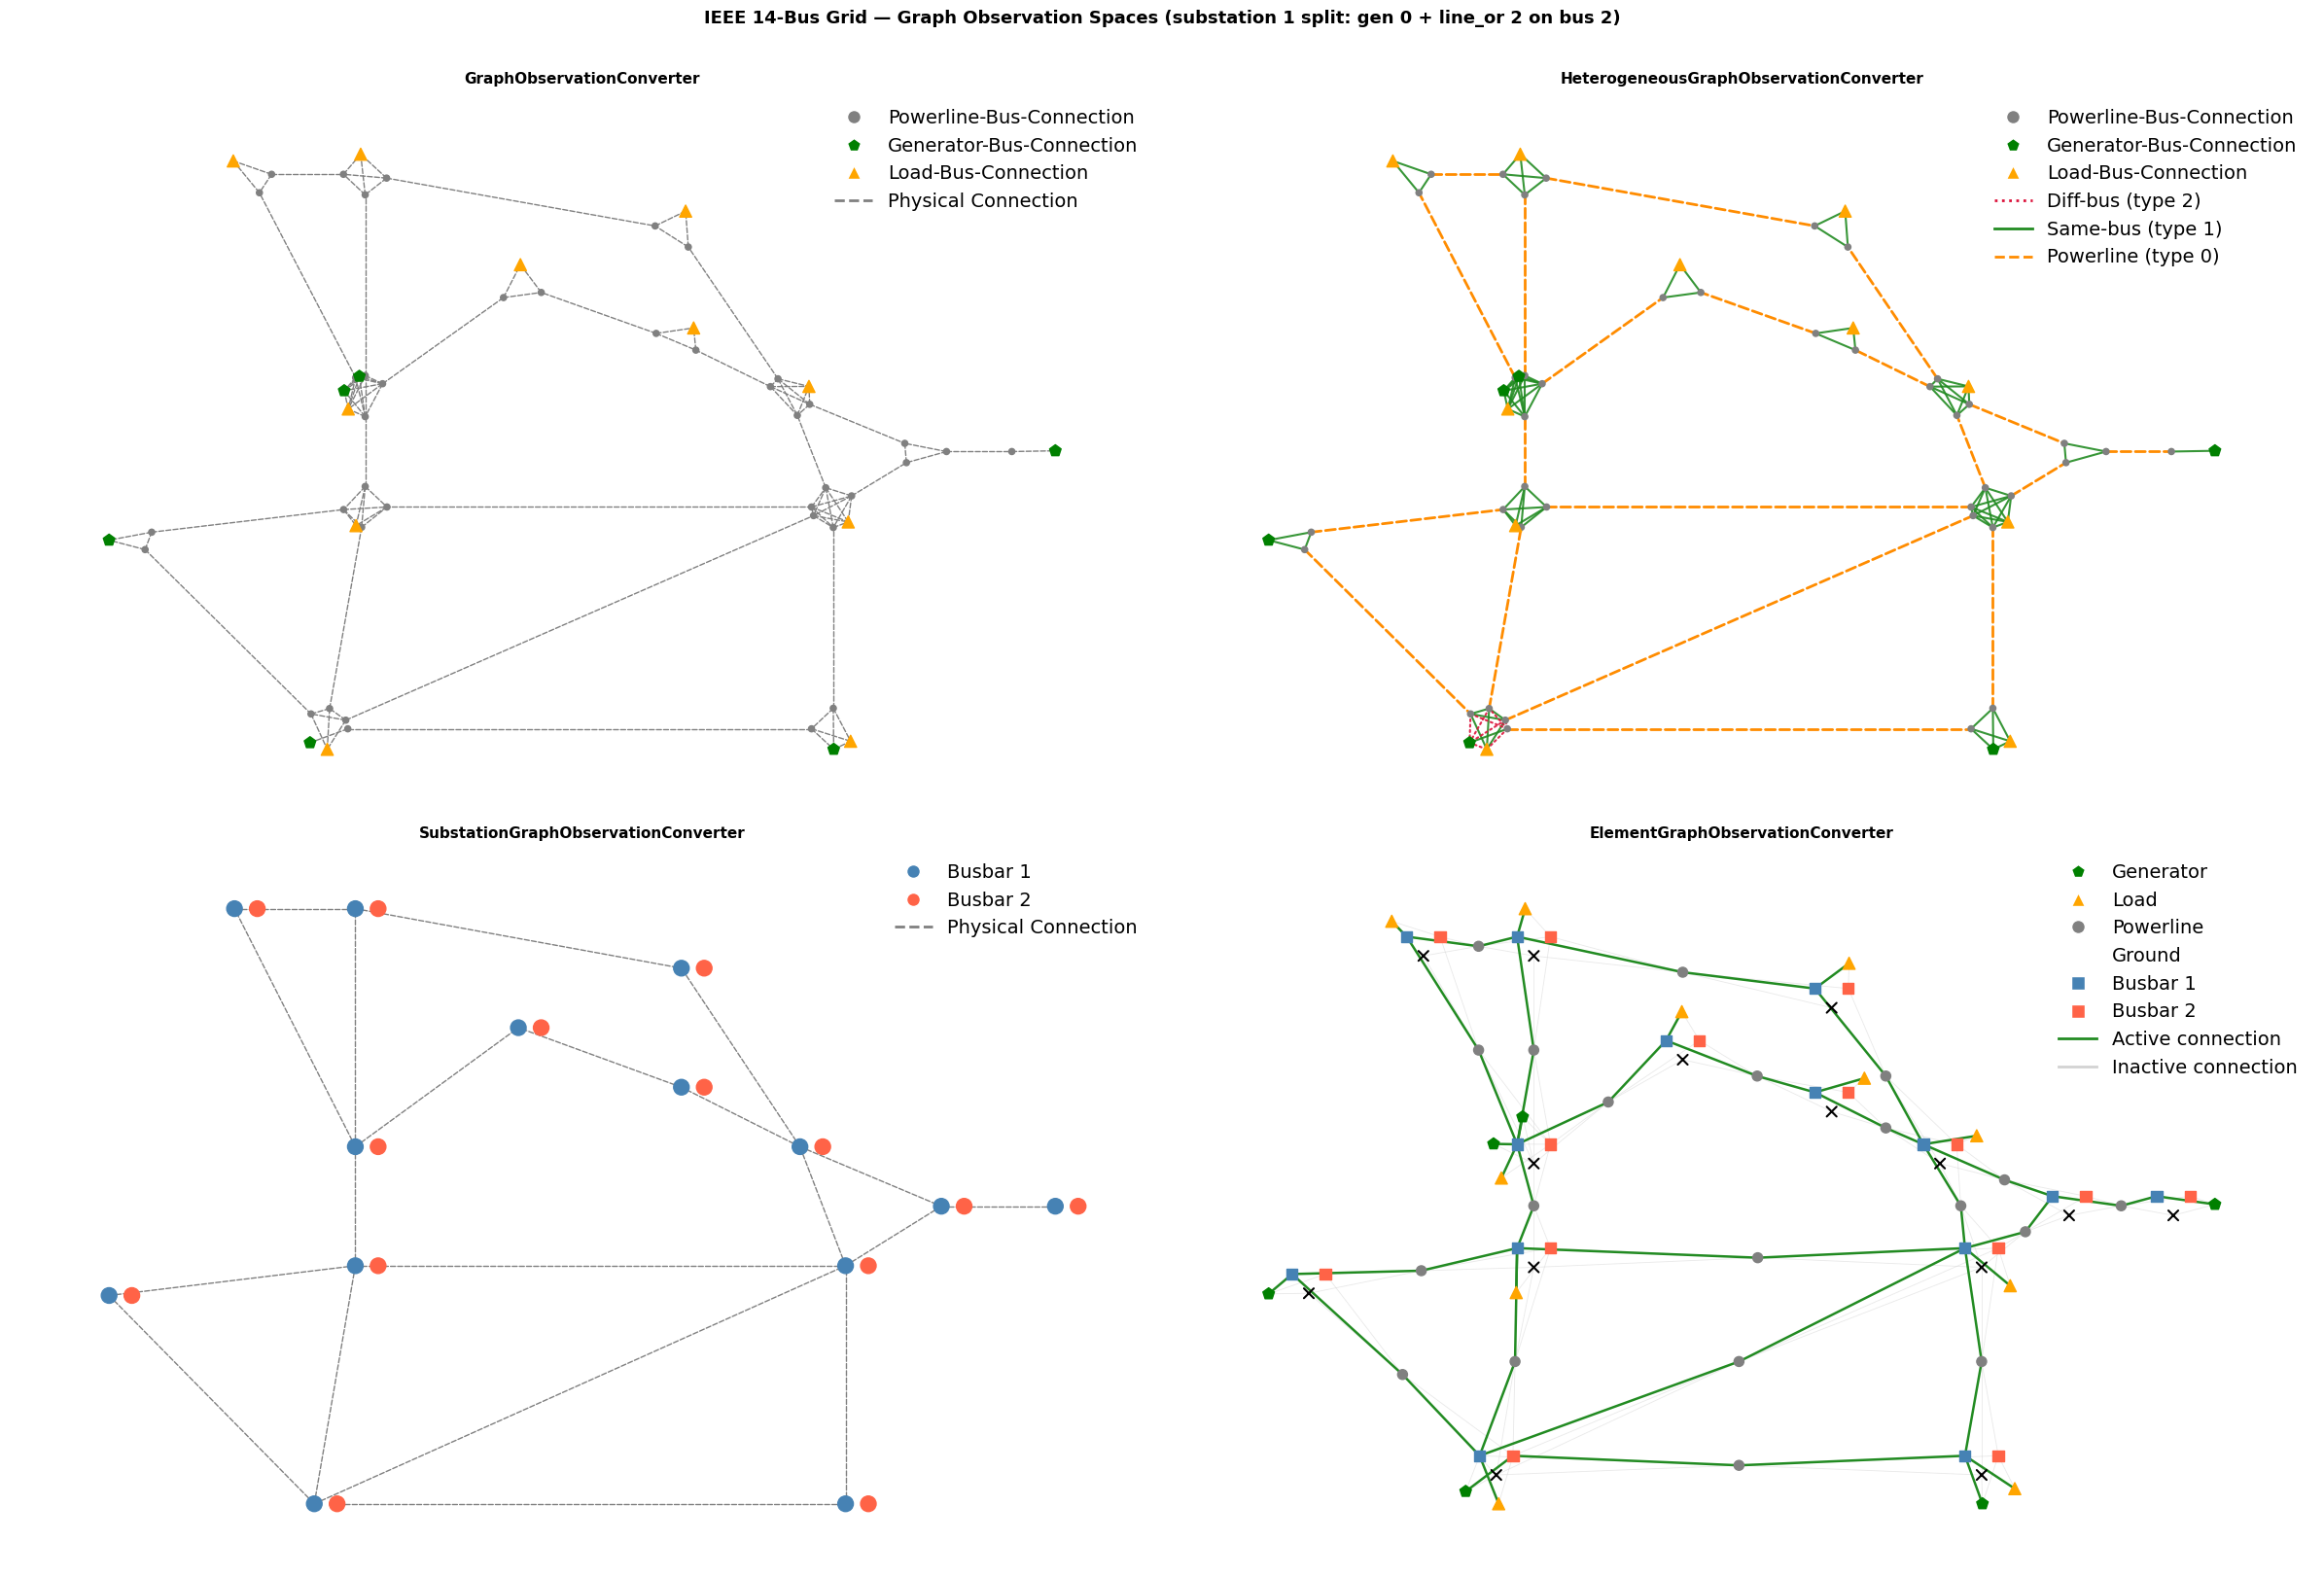

In [3]:
converters = [
    ("GraphObservationConverter",              GraphObservationConverter(env.observation_space)),
    ("HeterogeneousGraphObservationConverter", HeterogeneousGraphObservationConverter(env.observation_space)),
    ("SubstationGraphObservationConverter",    SubstationGraphObservationConverter(env.observation_space)),
    ("ElementGraphObservationConverter",       ElementGraphObservationConverter(env.observation_space)),
]

fig, axs = plt.subplots(2, 2, figsize=(24, 16), dpi=100)

for ax, (title, converter) in zip(axs.flat, converters):
    gym_obs     = converter.to_gym(obs)
    edge_mask   = gym_obs[EDGE_MASK].astype(bool)
    edge_index  = gym_obs[EDGE_INDEX][:, edge_mask]
    node_styles = get_node_styles(env, type(converter))
    edge_styles = get_edge_styles(gym_obs, type(converter))

    args = PlottingArgs(
        num_nodes=len(node_styles),
        powerline_edge_index=edge_index,
        node_styles=node_styles,
        edge_styles=edge_styles,
        show_legend=True,
    )
    visualize_graph(args, ax=ax)
    ax.set_title(title, fontsize=11, fontweight="bold")

plt.suptitle(
    "IEEE 14-Bus Grid — Graph Observation Spaces (substation 1 split: gen 0 + line_or 2 on bus 2)",
    fontsize=13, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.show()